In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Cargar dataset
df = pd.read_csv('../datos/Friday-02-03-2018_TrafficForML_CICFlowMeter.csv')

# Limpiar espacios en nombres de columnas
df.columns = df.columns.str.strip()

print("=" * 50)
print("INFORMACIÓN GENERAL DEL DATASET CIC-IDS-2018")
print("=" * 50)
print(f"Filas totales:     {df.shape[0]:,}")
print(f"Columnas totales:  {df.shape[1]}")
print(f"Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nTipos de datos:")
print(df.dtypes.value_counts())

INFORMACIÓN GENERAL DEL DATASET CIC-IDS-2018
Filas totales:     1,048,575
Columnas totales:  80
Memoria utilizada: 664.2 MB

Tipos de datos:
int64      41
float64    37
str         2
Name: count, dtype: int64


DISTRIBUCIÓN DE TIPOS DE TRÁFICO
Benign    :  762,384 flujos (72.7%)
Bot       :  286,191 flujos (27.3%)


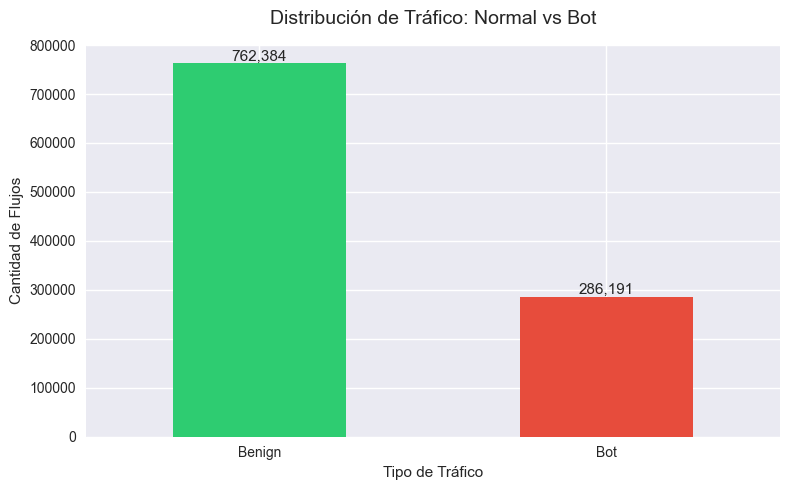

Gráfico guardado en resultados/


In [2]:
print("DISTRIBUCIÓN DE TIPOS DE TRÁFICO")
print("=" * 50)

conteo = df['Label'].value_counts()
porcentaje = df['Label'].value_counts(normalize=True) * 100

for label in conteo.index:
    print(f"{label:10s}: {conteo[label]:>8,} flujos ({porcentaje[label]:.1f}%)")

# Gráfico
fig, ax = plt.subplots(figsize=(8, 5))
conteo.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Distribución de Tráfico: Normal vs Bot', fontsize=14, pad=15)
ax.set_xlabel('Tipo de Tráfico')
ax.set_ylabel('Cantidad de Flujos')
ax.set_xticklabels(conteo.index, rotation=0)

for i, v in enumerate(conteo.values):
    ax.text(i, v + 5000, f'{v:,}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../resultados/distribucion_clases.png', dpi=150)
plt.show()
print("Gráfico guardado en resultados/")

In [3]:
print("ANÁLISIS DE VALORES PROBLEMÁTICOS")
print("=" * 50)

# Valores nulos
nulos = df.isnull().sum()
print(f"Columnas con valores nulos: {(nulos > 0).sum()}")
if (nulos > 0).sum() > 0:
    print(nulos[nulos > 0])

# Valores infinitos
inf_cols = []
for col in df.select_dtypes(include=[np.number]).columns:
    inf_count = np.isinf(df[col]).sum()
    if inf_count > 0:
        inf_cols.append((col, inf_count))

print(f"\nColumnas con valores infinitos: {len(inf_cols)}")
for col, count in inf_cols:
    print(f"  {col}: {count} valores infinitos")

# Valores negativos sospechosos
neg_cols = []
for col in df.select_dtypes(include=[np.number]).columns:
    if (df[col] < 0).any():
        neg_cols.append(col)

print(f"\nColumnas con valores negativos: {len(neg_cols)}")

ANÁLISIS DE VALORES PROBLEMÁTICOS
Columnas con valores nulos: 1
Flow Byts/s    2558
dtype: int64

Columnas con valores infinitos: 2
  Flow Byts/s: 1492 valores infinitos
  Flow Pkts/s: 4050 valores infinitos

Columnas con valores negativos: 2


TOP 10 CARACTERÍSTICAS POR VARIANZA
Flow Duration    9.072826e+14
Fwd IAT Tot      9.002966e+14
Bwd IAT Tot      5.517855e+14
Flow IAT Max     3.596822e+14
Fwd IAT Max      3.544826e+14
Idle Max         3.086374e+14
Idle Mean        3.032152e+14
Idle Min         3.004340e+14
Fwd IAT Min      2.840835e+14
Fwd IAT Mean     2.838478e+14
dtype: float64


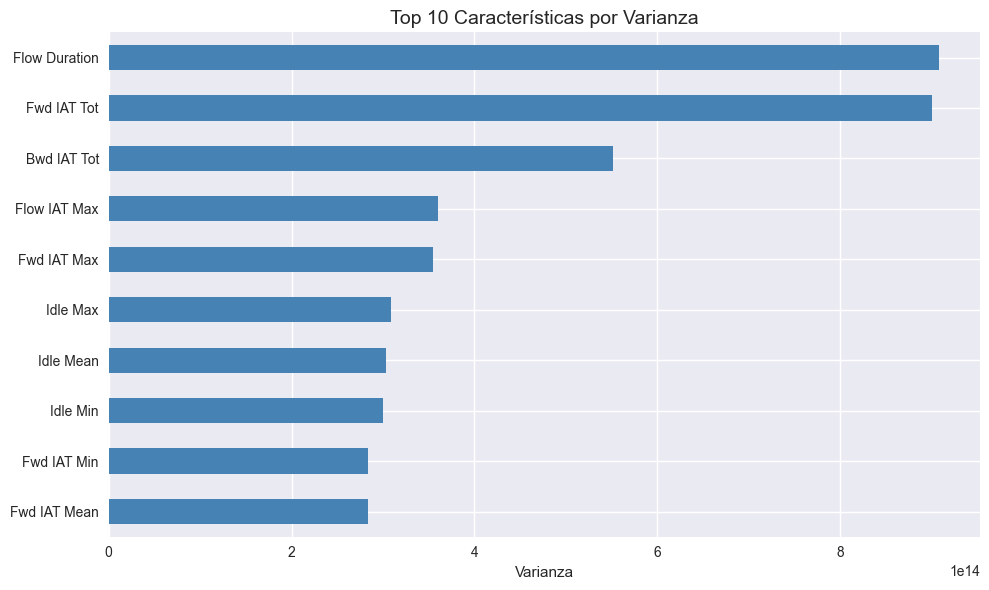

In [4]:
print("TOP 10 CARACTERÍSTICAS POR VARIANZA")
print("=" * 50)

# Solo columnas numéricas, excluyendo Label
numericas = df.select_dtypes(include=[np.number])

# Reemplazar infinitos temporalmente para calcular varianza
numericas_clean = numericas.replace([np.inf, -np.inf], np.nan)
varianzas = numericas_clean.var().sort_values(ascending=False)

top10 = varianzas.head(10)
print(top10)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))
top10.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Características por Varianza', fontsize=14)
ax.set_xlabel('Varianza')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../resultados/top10_features.png', dpi=150)
plt.show()

In [5]:
print("COMPARACIÓN ESTADÍSTICA: BENIGN vs BOT")
print("=" * 50)

from scipy import stats

benign = df[df['Label'] == 'Benign']
bot = df[df['Label'] == 'Bot']

# Analizar 3 features clave
features_analizar = ['Flow Duration', 'Tot Fwd Pkts', 'Fwd Pkt Len Mean']

for feature in features_analizar:
    try:
        b_mean = benign[feature].replace([np.inf, -np.inf], np.nan).dropna().mean()
        bot_mean = bot[feature].replace([np.inf, -np.inf], np.nan).dropna().mean()
        
        t_stat, p_value = stats.ttest_ind(
            benign[feature].replace([np.inf, -np.inf], np.nan).dropna().sample(10000, random_state=42),
            bot[feature].replace([np.inf, -np.inf], np.nan).dropna().sample(10000, random_state=42)
        )
        
        print(f"\n{feature}:")
        print(f"  Benign media: {b_mean:.2f}")
        print(f"  Bot media:    {bot_mean:.2f}")
        print(f"  p-value:      {p_value:.6f}")
        print(f"  Diferencia significativa: {'SÍ' if p_value < 0.05 else 'NO'}")
    except Exception as e:
        print(f"  Error en {feature}: {e}")

COMPARACIÓN ESTADÍSTICA: BENIGN vs BOT

Flow Duration:
  Benign media: 15808256.13
  Bot media:    75298.91
  p-value:      0.000000
  Diferencia significativa: SÍ

Tot Fwd Pkts:
  Benign media: 7.13
  Bot media:    2.57
  p-value:      0.000032
  Diferencia significativa: SÍ

Fwd Pkt Len Mean:
  Benign media: 55.29
  Bot media:    52.83
  p-value:      0.000985
  Diferencia significativa: SÍ


In [6]:
print("RESUMEN PARA TESIS")
print("=" * 50)

resumen = {
    'archivo': 'Friday-02-03-2018_TrafficForML_CICFlowMeter.csv',
    'total_filas': df.shape[0],
    'total_columnas': df.shape[1],
    'clases': df['Label'].value_counts().to_dict(),
    'valores_infinitos': len(inf_cols),
    'columnas_con_nulos': int((nulos > 0).sum())
}

import json
with open('../resultados/resumen_dataset.json', 'w') as f:
    json.dump(resumen, f, indent=2)

print("Resumen guardado en resultados/resumen_dataset.json")
print("\nEste análisis forma parte del Capítulo 3 de tu tesis.")
print("Sección 3.4: Descripción del dataset utilizado.")

# Commit a GitHub
import subprocess
subprocess.run(['git', 'add', '.'], cwd='C:/tesis-fl-ids')
subprocess.run(['git', 'commit', '-m', 
    'feat: exploracion inicial CIC-IDS-2018 viernes Bot vs Benign'],
    cwd='C:/tesis-fl-ids')
print("\nCambios guardados en Git.")

RESUMEN PARA TESIS
Resumen guardado en resultados/resumen_dataset.json

Este análisis forma parte del Capítulo 3 de tu tesis.
Sección 3.4: Descripción del dataset utilizado.

Cambios guardados en Git.
